In [1]:
import pandas as pd

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.linear_model import LinearRegression

In [5]:
np.random.seed(42)
num_samples=500
years_of_experience = np.random.randint(2,21,size=num_samples)
slope = (200_000 - 60_000)/18
intercept = 60_000
salaries = slope*years_of_experience+intercept+np.random.normal(0, 10_000)
data={'Years_of_Experience': years_of_experience, 'Salary': salaries}
df = pd.DataFrame(data)

In [6]:
df.describe()

,Years_of_Experience,Salary
count,500.000000,500.000000
mean,10.616000,135384.446676
std,5.662922,44044.945994
min,2.000000,68371.113343
25%,5.750000,97537.780010
50%,10.000000,130593.335565
75%,16.000000,177260.002232
max,20.000000,208371.113343


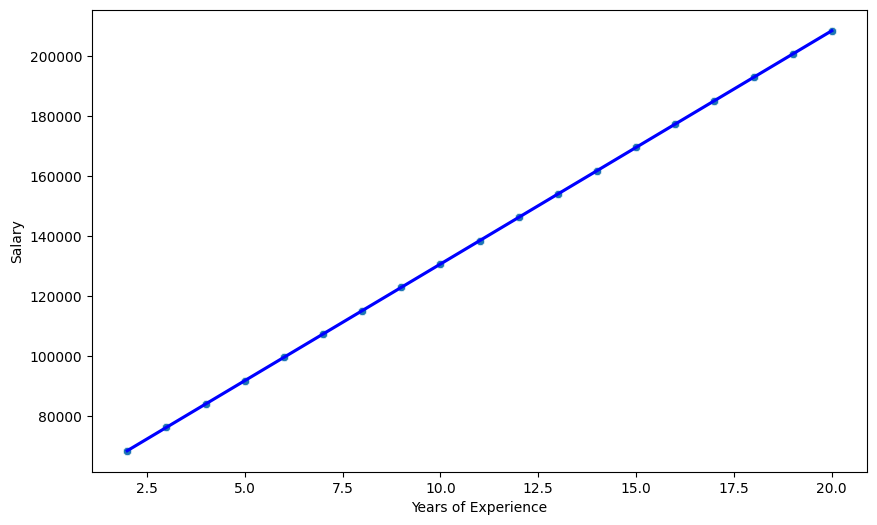

In [11]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Years_of_Experience', y='Salary', data=df)
sns.regplot(x='Years_of_Experience', y='Salary', data=df, scatter=False, color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()


In [10]:
print(df.columns)



Index(['Years_of_Experience', 'Salary'], dtype='object')


In [12]:
X = df[['Years_of_Experience']]

In [13]:
y = df['Salary']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [16]:
lr = LinearRegression()

In [17]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
lr.score(X_train, y_train)

1.0

In [20]:
lr.score(X_test, y_test)

1.0

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [23]:
y_pred = lr.predict(X_test)

In [24]:
mean_absolute_error(y_test, y_pred)

1.5425030142068864e-11

In [25]:
mean_squared_error(y_test, y_pred)

4.446922973085077e-22

In [26]:
r2_score(y_test, y_pred)

1.0

In [27]:
lr.coef_

array([7777.77777778])

In [28]:
lr.intercept_

np.float64(52815.5577874756)

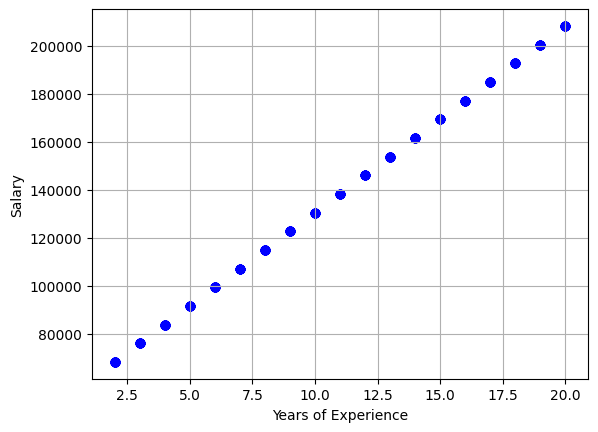

In [29]:
coefficients = lr.coef_
intercept = lr.intercept_
x=np.linspace(0,20,100)
y = coefficients*X + intercept
plt.scatter(X,y, label=f'y = {coefficients[0]}x + {intercept}', color='blue')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.grid()
plt.show()